In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")

print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# Download stock price data
ticker = "AAPL"  # Apple
df = yf.download(ticker, start="2020-01-01", end="2025-01-01")

df.head()


C:\Users\Lovro\AppData\Local\Temp\ipykernel_2704\295259646.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468269,72.528589,71.223267,71.476607,135480400
2020-01-03,71.763741,72.523769,71.539352,71.696183,146322800
2020-01-06,72.335564,72.374169,70.634547,70.885479,118387200
2020-01-07,71.995346,72.600952,71.775781,72.345197,108872000
2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200


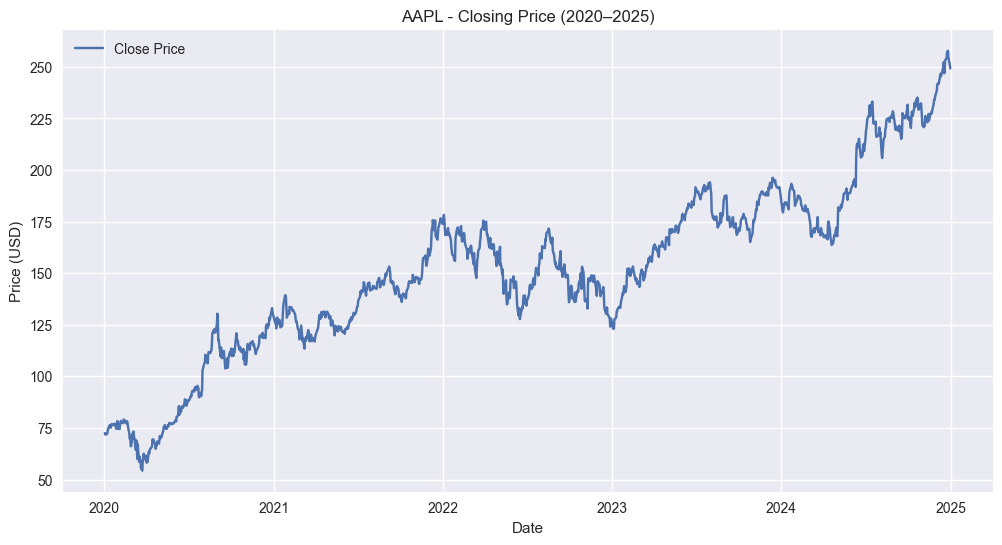

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price')
plt.title("AAPL - Closing Price (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


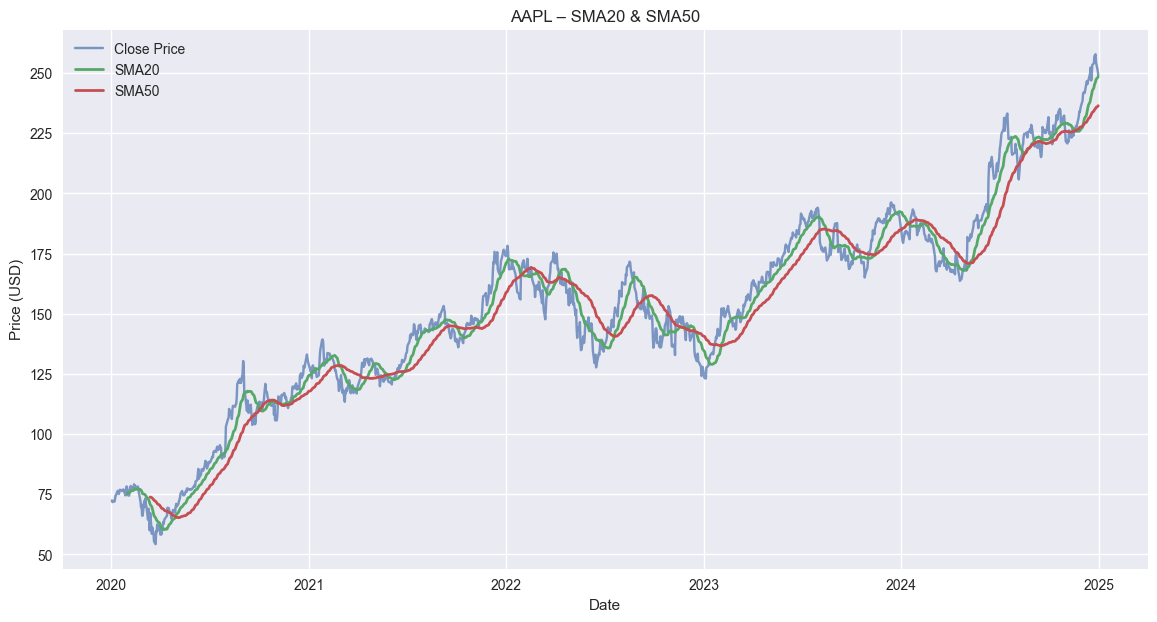

In [5]:
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['SMA20'], label='SMA20', linewidth=2)
plt.plot(df['SMA50'], label='SMA50', linewidth=2)

plt.title("AAPL – SMA20 & SMA50")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


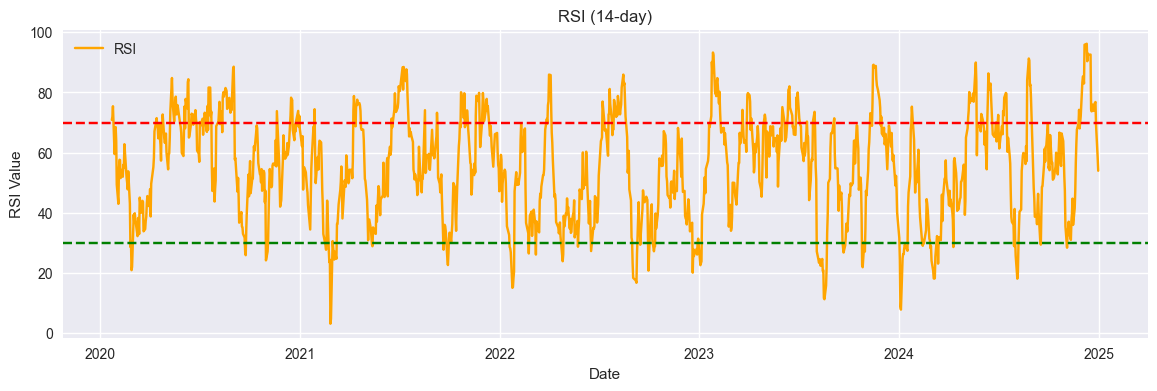

In [6]:
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

RS = gain / loss
df['RSI'] = 100 - (100 / (1 + RS))

plt.figure(figsize=(14,4))
plt.plot(df['RSI'], label='RSI', color='orange')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title("RSI (14-day)")
plt.xlabel("Date")
plt.ylabel("RSI Value")
plt.legend()
plt.grid(True)
plt.show()


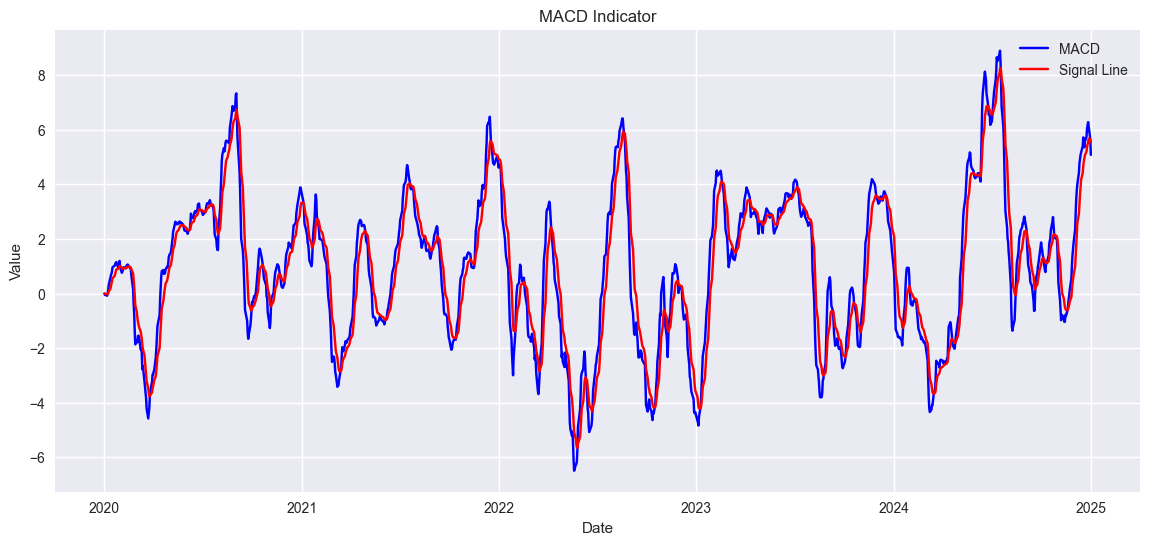

In [7]:
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

plt.figure(figsize=(14,6))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['Signal'], label='Signal Line', color='red')
plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


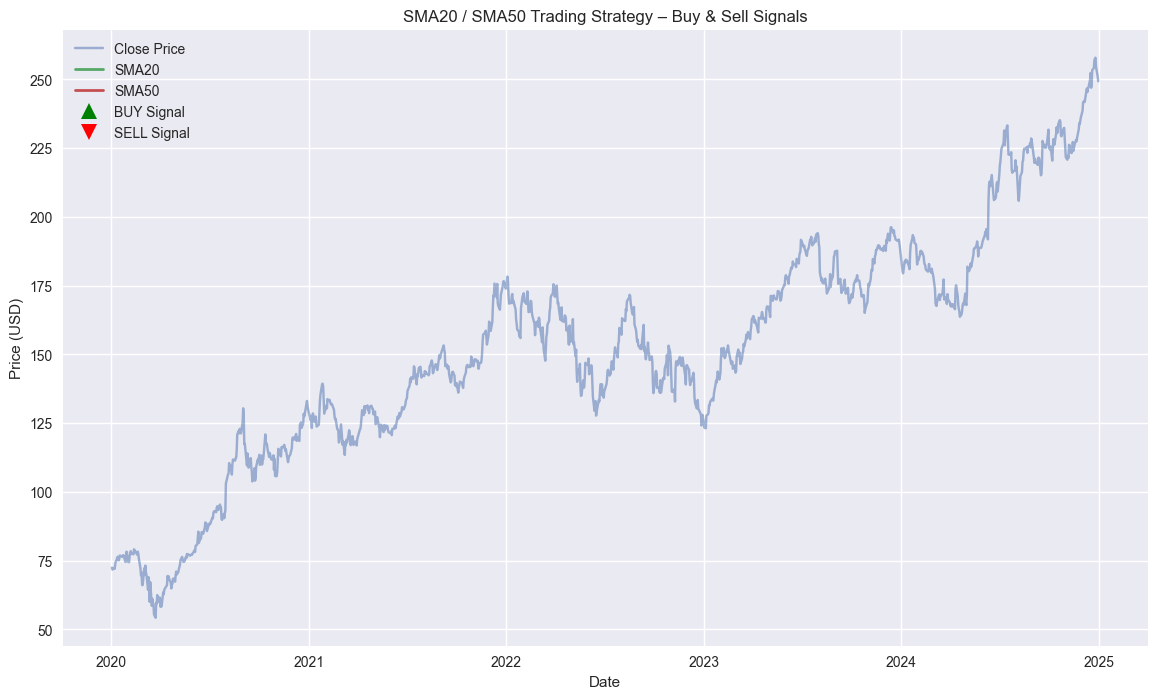

In [8]:
# SMA calculations
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

# BUY/SELL signals
df['Signal'] = 0
df['Signal'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)
df['Position'] = df['Signal'].diff()

# Plot
plt.figure(figsize=(14,8))
plt.plot(df['Close'], label='Close Price', alpha=0.5)
plt.plot(df['SMA20'], label='SMA20', linewidth=2)
plt.plot(df['SMA50'], label='SMA50', linewidth=2)

# BUY signals
plt.plot(df[df['Position'] == 1].index,
         df['SMA20'][df['Position'] == 1],
         '^', markersize=12, color='green', label='BUY Signal')

# SELL signals
plt.plot(df[df['Position'] == -1].index,
         df['SMA20'][df['Position'] == -1],
         'v', markersize=12, color='red', label='SELL Signal')

plt.title("SMA20 / SMA50 Trading Strategy – Buy & Sell Signals")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


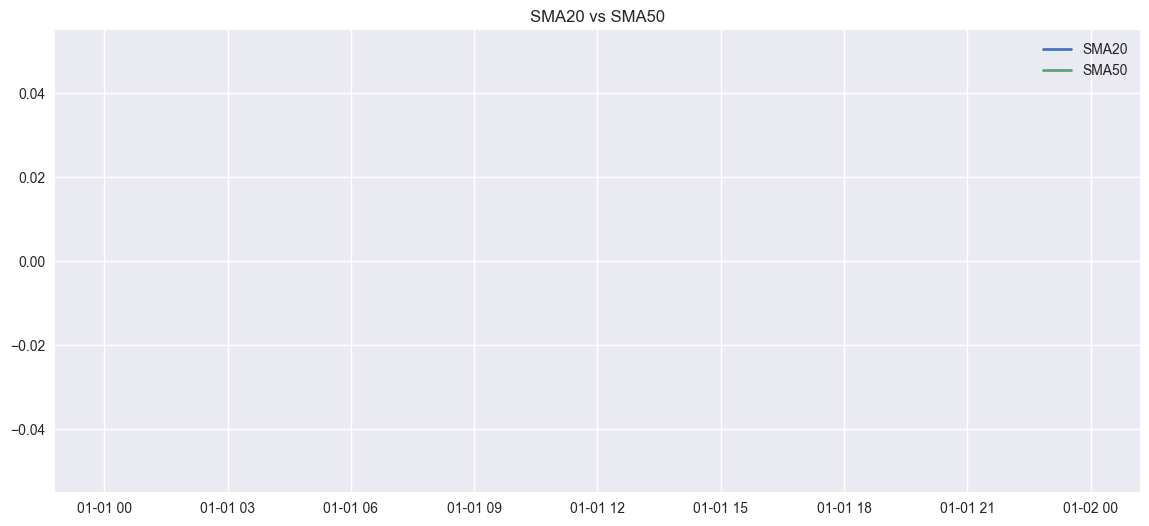

In [9]:
plt.figure(figsize=(14,6))
plt.plot(df['SMA20'], label='SMA20', linewidth=2)
plt.plot(df['SMA50'], label='SMA50', linewidth=2)
plt.title("SMA20 vs SMA50")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

df[['Close', 'SMA20', 'SMA50']].head(20)


Price,Close,SMA20,SMA50
Ticker,AAPL,,
Date,,,
2020-01-02,72.468269,NaN,NaN
2020-01-03,71.763741,NaN,NaN
2020-01-06,72.335564,NaN,NaN
2020-01-07,71.995346,NaN,NaN
2020-01-08,73.153488,NaN,NaN
2020-01-09,74.707352,NaN,NaN
2020-01-10,74.876228,NaN,NaN
2020-01-13,76.475899,NaN,NaN


In [11]:
df[['Close', 'SMA20', 'SMA50']].tail(15)


Price,Close,SMA20,SMA50
Ticker,AAPL,,
Date,,,
2024-12-10,246.654434,NaN,NaN
2024-12-11,245.380203,NaN,NaN
2024-12-12,246.843597,NaN,NaN
2024-12-13,247.012833,NaN,NaN
2024-12-16,249.909714,NaN,NaN
2024-12-17,252.338730,NaN,NaN
2024-12-18,246.933182,NaN,NaN
2024-12-19,248.665359,NaN,NaN


In [12]:
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

df[['Close', 'SMA20', 'SMA50']].head(60)


Price,Close,SMA20,SMA50
Ticker,AAPL,,
Date,,,
2020-01-02,72.468269,NaN,NaN
2020-01-03,71.763741,NaN,NaN
2020-01-06,72.335564,NaN,NaN
2020-01-07,71.995346,NaN,NaN
2020-01-08,73.153488,NaN,NaN
2020-01-09,74.707352,NaN,NaN
2020-01-10,74.876228,NaN,NaN
2020-01-13,76.475899,NaN,NaN


In [13]:
df.columns


MultiIndex([(   'Close', 'AAPL'),
            (    'High', 'AAPL'),
            (     'Low', 'AAPL'),
            (    'Open', 'AAPL'),
            (  'Volume', 'AAPL'),
            (   'SMA20',     ''),
            (   'SMA50',     ''),
            (     'RSI',     ''),
            (   'EMA12',     ''),
            (   'EMA26',     ''),
            (    'MACD',     ''),
            (  'Signal',     ''),
            ('Position',     '')],
           names=['Price', 'Ticker'])

In [14]:
# Pretvorimo MultiIndex stupce u obične stupce
df.columns = df.columns.get_level_values(0)

df.head()


Price,Close,High,Low,Open,Volume,SMA20,SMA50,RSI,EMA12,EMA26,MACD,Signal,Position
Date,,,,,,,,,,,,,
2020-01-02,72.468269,72.528589,71.223267,71.476607,135480400,NaN,NaN,NaN,72.468269,72.468269,0.000000,0,NaN
2020-01-03,71.763741,72.523769,71.539352,71.696183,146322800,NaN,NaN,NaN,72.359880,72.416082,-0.056202,0,0.0
2020-01-06,72.335564,72.374169,70.634547,70.885479,118387200,NaN,NaN,NaN,72.356139,72.410118,-0.053978,0,0.0
2020-01-07,71.995346,72.600952,71.775781,72.345197,108872000,NaN,NaN,NaN,72.300633,72.379394,-0.078761,0,0.0
2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200,NaN,NaN,NaN,72.431841,72.436734,-0.004893,0,0.0


In [15]:
# Izračun pokretnih prosjeka
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

df[['Close', 'SMA20', 'SMA50']].head(20)


Price,Close,SMA20,SMA50
Date,,,
2020-01-02,72.468269,NaN,NaN
2020-01-03,71.763741,NaN,NaN
2020-01-06,72.335564,NaN,NaN
2020-01-07,71.995346,NaN,NaN
2020-01-08,73.153488,NaN,NaN
2020-01-09,74.707352,NaN,NaN
2020-01-10,74.876228,NaN,NaN
2020-01-13,76.475899,NaN,NaN
2020-01-14,75.443230,NaN,NaN


In [16]:
# Izračun RSI (14)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

RS = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + RS))

df[['Close', 'RSI']].head(25)


Price,Close,RSI
Date,,
2020-01-02,72.468269,NaN
2020-01-03,71.763741,NaN
2020-01-06,72.335564,NaN
2020-01-07,71.995346,NaN
2020-01-08,73.153488,NaN
2020-01-09,74.707352,NaN
2020-01-10,74.876228,NaN
2020-01-13,76.475899,NaN
2020-01-14,75.443230,NaN


In [17]:
# MACD indikator
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()

df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

df[['Close', 'EMA12', 'EMA26', 'MACD', 'Signal']].head(30)


Price,Close,EMA12,EMA26,MACD,Signal
Date,,,,,
2020-01-02,72.468269,72.468269,72.468269,0.000000,0.000000
2020-01-03,71.763741,72.359880,72.416082,-0.056202,-0.011240
2020-01-06,72.335564,72.356139,72.410118,-0.053978,-0.019788
2020-01-07,71.995346,72.300633,72.379394,-0.078761,-0.031583
2020-01-08,73.153488,72.431841,72.436734,-0.004893,-0.026245
2020-01-09,74.707352,72.781920,72.604928,0.176992,0.014403
2020-01-10,74.876228,73.104121,72.773173,0.330948,0.077712
2020-01-13,76.475899,73.622856,73.047449,0.575408,0.177251
2020-01-14,75.443230,73.902914,73.224914,0.678000,0.277401


In [18]:
# Buy & Sell signali na MACD-u
df['Position'] = 0
df.loc[df['MACD'] > df['Signal'], 'Position'] = 1
df.loc[df['MACD'] < df['Signal'], 'Position'] = -1

df[['MACD', 'Signal', 'Position']].head(30)


Price,MACD,Signal,Position
Date,,,
2020-01-02,0.000000,0.000000,0
2020-01-03,-0.056202,-0.011240,-1
2020-01-06,-0.053978,-0.019788,-1
2020-01-07,-0.078761,-0.031583,-1
2020-01-08,-0.004893,-0.026245,1
2020-01-09,0.176992,0.014403,1
2020-01-10,0.330948,0.077712,1
2020-01-13,0.575408,0.177251,1
2020-01-14,0.678000,0.277401,1


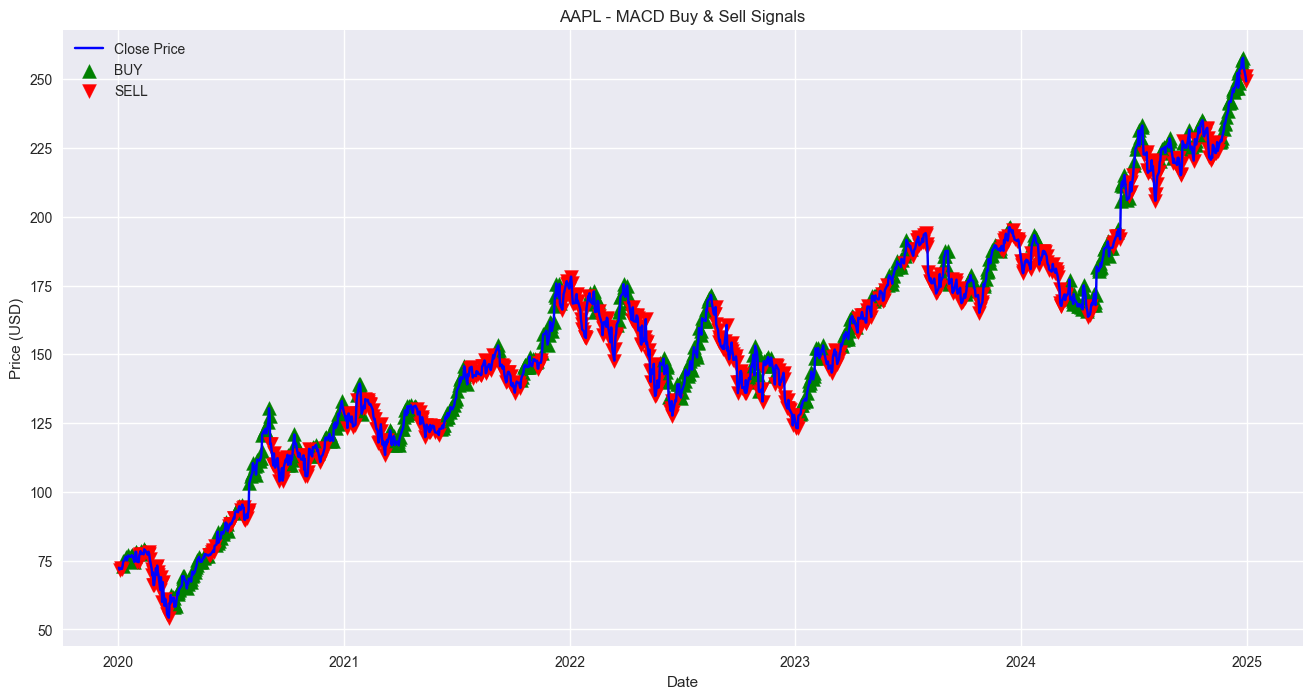

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

# Glavna cijena
plt.plot(df.index, df['Close'], label='Close Price', color='blue')

# BUY signali (zeleno)
plt.scatter(df.index[df['Position'] == 1],
            df['Close'][df['Position'] == 1],
            marker='^', color='green', s=100, label='BUY')

# SELL signali (crveno)
plt.scatter(df.index[df['Position'] == -1],
            df['Close'][df['Position'] == -1],
            marker='v', color='red', s=100, label='SELL')

plt.title("AAPL - MACD Buy & Sell Signals")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


In [20]:
# Resetiramo signale
df['Buy_Signal'] = 0
df['Sell_Signal'] = 0

# Generiramo buy/sell signale samo kad MACD presječe Signal liniju
for i in range(1, len(df)):
    # BUY: MACD prijeđe iznad Signal linije
    if df['MACD'].iloc[i] > df['Signal'].iloc[i] and df['MACD'].iloc[i-1] <= df['Signal'].iloc[i-1]:
        df['Buy_Signal'].iloc[i] = 1
    # SELL: MACD padne ispod Signal linije
    elif df['MACD'].iloc[i] < df['Signal'].iloc[i] and df['MACD'].iloc[i-1] >= df['Signal'].iloc[i-1]:
        df['Sell_Signal'].iloc[i] = 1


C:\Users\Lovro\AppData\Local\Temp\ipykernel_2704\1921308820.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sell_Signal'].iloc[i] = 1
C:\Users\Lovro\AppData\Local\Temp\ipykernel_2704\1921308820.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Buy_Signal'].iloc[i] = 1
C:\Users\Lovro\AppData\Local\Temp\ipykernel_2704\1921308820.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sell_Signal'].iloc[i] = 1
C:\Users\Lov

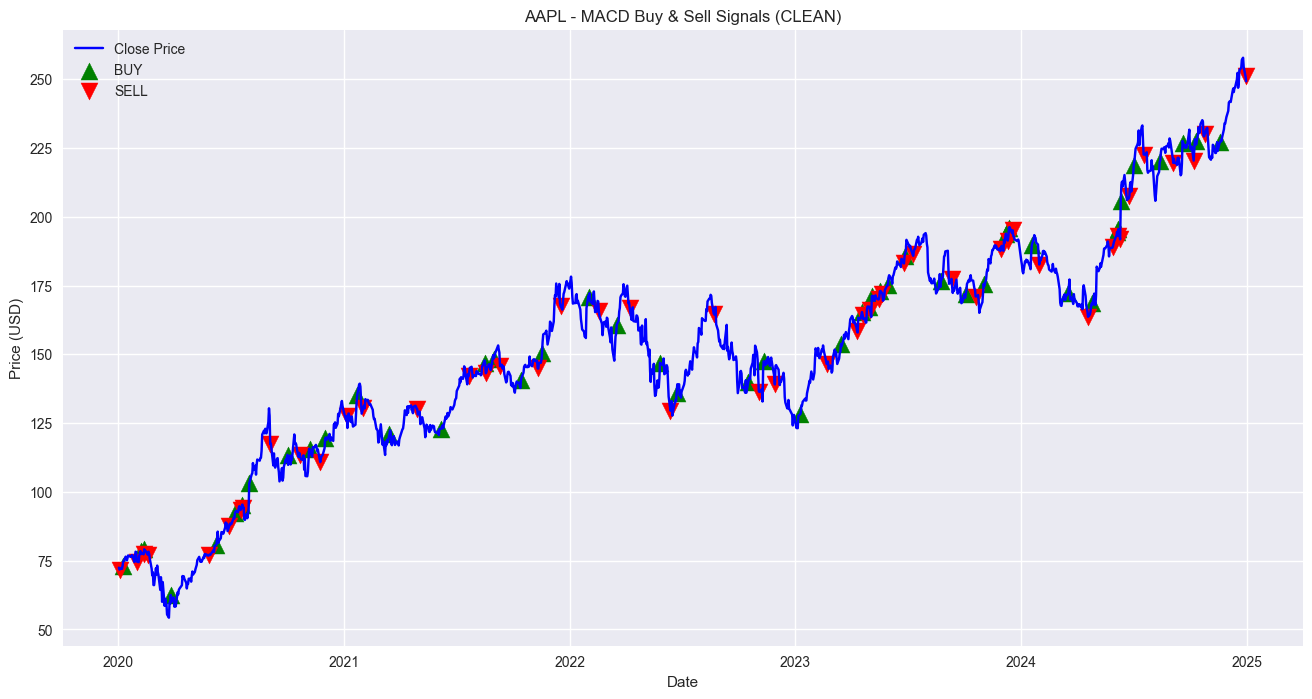

In [21]:
plt.figure(figsize=(16,8))

# Close cijena
plt.plot(df.index, df['Close'], label='Close Price', color='blue')

# BUY signali (zelene strelice prema gore)
plt.scatter(df.index[df['Buy_Signal'] == 1],
            df['Close'][df['Buy_Signal'] == 1],
            marker='^', color='green', s=150, label='BUY')

# SELL signali (crvene strelice prema dolje)
plt.scatter(df.index[df['Sell_Signal'] == 1],
            df['Close'][df['Sell_Signal'] == 1],
            marker='v', color='red', s=150, label='SELL')

plt.title("AAPL - MACD Buy & Sell Signals (CLEAN)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
# 1) Dnevni prinos dionice (buy & hold)
df['Return'] = df['Close'].pct_change()

# 2) Prinos strategije (ovisno o poziciji: -1, 0, 1)
df['Strategy_Return'] = df['Return'] * df['Position'].shift(1)
df['Strategy_Return'] = df['Strategy_Return'].fillna(0)

# 3) Kumulativna vrijednost portfelja (pretpostavimo start = 1)
df['Equity_BuyHold'] = (1 + df['Return']).cumprod()
df['Equity_Strategy'] = (1 + df['Strategy_Return']).cumprod()

# Pogledajmo prvih par redova da vidimo je li sve ok
df[['Close', 'Return', 'Strategy_Return', 'Equity_BuyHold', 'Equity_Strategy']].head(15)


Price,Close,Return,Strategy_Return,Equity_BuyHold,Equity_Strategy
Date,,,,,
2020-01-02,72.468269,NaN,0.000000,NaN,1.000000
2020-01-03,71.763741,-0.009722,-0.000000,0.990278,1.000000
2020-01-06,72.335564,0.007968,-0.007968,0.998169,0.992032
2020-01-07,71.995346,-0.004703,0.004703,0.993474,0.996698
2020-01-08,73.153488,0.016086,-0.016086,1.009455,0.980664
2020-01-09,74.707352,0.021241,0.021241,1.030897,1.001495
2020-01-10,74.876228,0.002261,0.002261,1.033228,1.003759
2020-01-13,76.475899,0.021364,0.021364,1.055302,1.025203
2020-01-14,75.443230,-0.013503,-0.013503,1.041052,1.011360


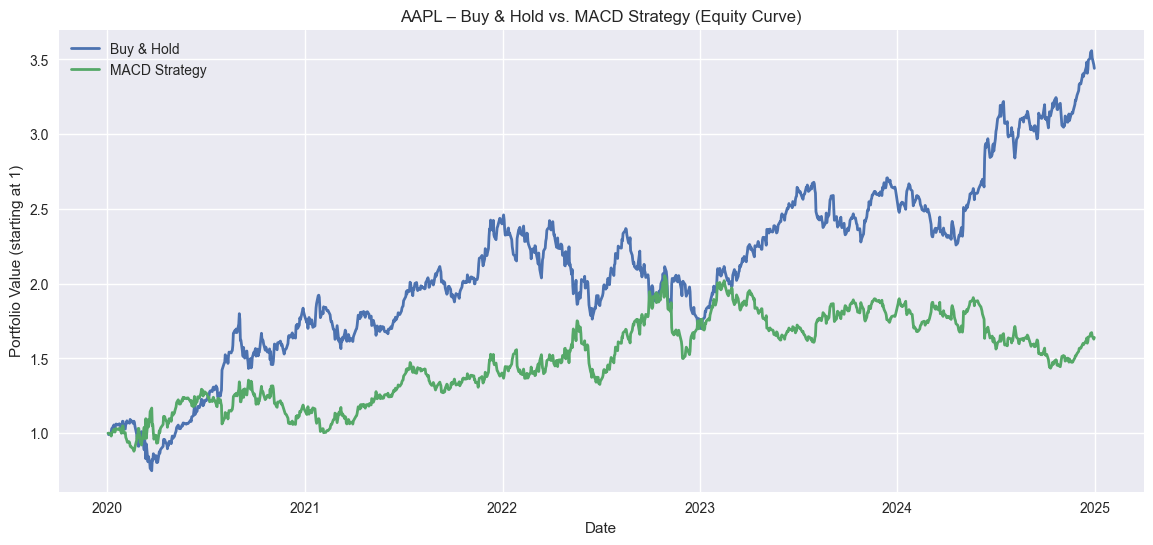

In [23]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Equity_BuyHold'], label='Buy & Hold', linewidth=2)
plt.plot(df.index, df['Equity_Strategy'], label='MACD Strategy', linewidth=2)

plt.title("AAPL – Buy & Hold vs. MACD Strategy (Equity Curve)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (starting at 1)")
plt.grid(True)
plt.legend()
plt.show()


In [24]:
import numpy as np

# 1) Dnevni prinosi (bez NaN)
daily_ret_stock = df['Return'].dropna()
daily_ret_strat = df['Strategy_Return'].dropna()

def performance_stats(equity, daily_ret):
    total_return = equity.iloc[-1] - 1  # ukupni prinos
    n_days = len(daily_ret)

    # Godišnji prinos (CAGR)
    cagr = equity.iloc[-1] ** (252 / n_days) - 1

    # Volatilnost i Sharpe
    vol = daily_ret.std() * np.sqrt(252)
    sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252)

    # Max drawdown
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()

    return total_return, cagr, vol, sharpe, max_dd

bh_stats = performance_stats(df['Equity_BuyHold'], df['Equity_BuyHold'].pct_change().dropna())
strat_stats = performance_stats(df['Equity_Strategy'], df['Equity_Strategy'].pct_change().dropna())

print("=== Buy & Hold AAPL ===")
print(f"Ukupni prinos:       {bh_stats[0]:.2%}")
print(f"Godišnji prinos:     {bh_stats[1]:.2%}")
print(f"Volatilnost:         {bh_stats[2]:.2%}")
print(f"Sharpe ratio:        {bh_stats[3]:.2f}")
print(f"Max drawdown:        {bh_stats[4]:.2%}")
print()
print("=== MACD Strategija ===")
print(f"Ukupni prinos:       {strat_stats[0]:.2%}")
print(f"Godišnji prinos:     {strat_stats[1]:.2%}")
print(f"Volatilnost:         {strat_stats[2]:.2%}")
print(f"Sharpe ratio:        {strat_stats[3]:.2f}")
print(f"Max drawdown:        {strat_stats[4]:.2%}")


=== Buy & Hold AAPL ===
Ukupni prinos:       244.00%
Godišnji prinos:     28.13%
Volatilnost:         31.69%
Sharpe ratio:        0.95
Max drawdown:        -31.43%

=== MACD Strategija ===
Ukupni prinos:       64.01%
Godišnji prinos:     10.43%
Volatilnost:         31.72%
Sharpe ratio:        0.47
Max drawdown:        -30.13%


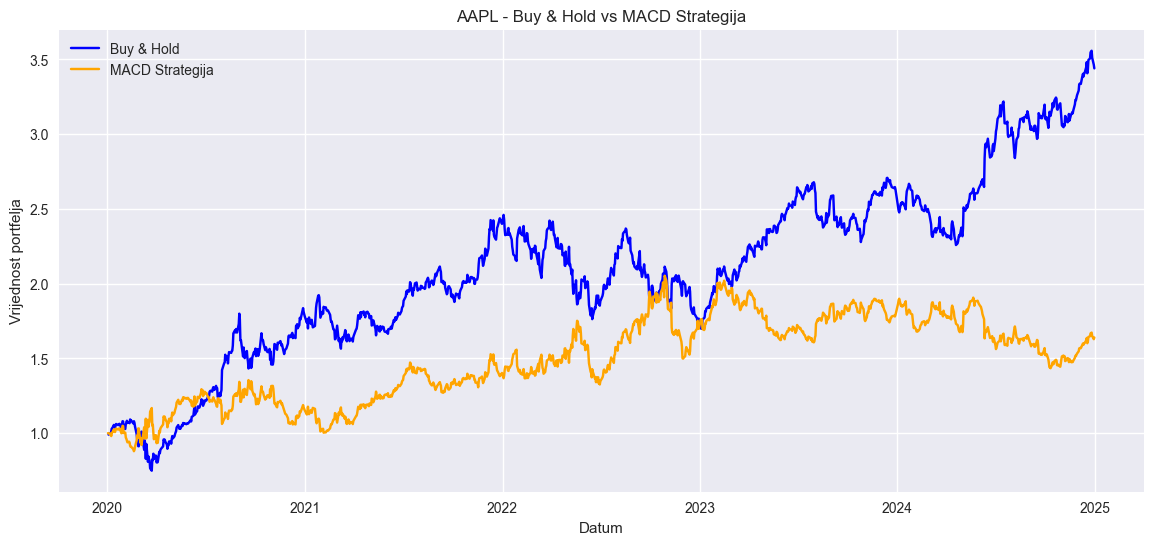

In [25]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Equity_BuyHold'], label='Buy & Hold', color='blue')
plt.plot(df.index, df['Equity_Strategy'], label='MACD Strategija', color='orange')
plt.title('AAPL - Buy & Hold vs MACD Strategija')
plt.xlabel('Datum')
plt.ylabel('Vrijednost portfelja')
plt.legend()
plt.grid(True)
plt.show()
